# NQM Media Smooth Template

Focused notebook for editing `media_3y3m_spread_pp_full_dscr_doc` in the NONQM refi fixed JSON model.

The source JSON is copied into `smooth/local_models/`. Edits are written as a separate `*.smooth_edit.json` file next to that local baseline. The template is a no-op for now: each edited curve starts equal to the original curve.

In [2]:
from __future__ import annotations

import copy
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from smooth_utils import (
    curve_to_df,
    edited_output_path,
    ensure_local_model_copy,
    find_curve,
    list_curves,
    read_model_json,
    rebuild_curve,
    update_curve,
    write_model_json,
)

SOURCE_MODEL_PATH = Path(
    r"C:\Git\LMSimData\data\NONQM\ModelFiles\1.8.0\refi_fixed_v1_2026_07_06_10_16_15.879723.json"
)
LOCAL_MODELS_DIR = Path(r"s:\QR\hzeng\howard-toolbox\smooth\local_models")
LOCAL_MODEL_PATH = LOCAL_MODELS_DIR / SOURCE_MODEL_PATH.name
OUTPUT_PATH = edited_output_path(LOCAL_MODEL_PATH)

CURVE_NAME = "media_3y3m_spread_pp_full_dscr_doc"
SELECTOR_VALUES = (
    "pp_active_N_other_doc",
    "pp_active_N_full_doc",
    "pp_active_N_dscr_doc",
    "pp_active_Y",
)

ensure_local_model_copy(SOURCE_MODEL_PATH, LOCAL_MODEL_PATH)
model = read_model_json(LOCAL_MODEL_PATH)
model_edit = copy.deepcopy(model)

LOCAL_MODEL_PATH

Using existing local baseline copy: s:\QR\hzeng\howard-toolbox\smooth\local_models\refi_fixed_v1_2026_07_06_10_16_15.879723.json


WindowsPath('s:/QR/hzeng/howard-toolbox/smooth/local_models/refi_fixed_v1_2026_07_06_10_16_15.879723.json')

In [3]:
media_curves = list_curves(model, contains="media_3y3m_spread_pp_full_dscr_doc")
media_curves

,group,name,selector_field,selector_value,n_points,x_min,x_max,y_min,y_max
0,interaction,media_3y3m_spread_pp_full_dscr_doc,pp_full_dscr_doc,pp_active_N_other_doc,200,-0.05,0.6,-0.171012,0.217599
1,interaction,media_3y3m_spread_pp_full_dscr_doc,pp_full_dscr_doc,pp_active_N_full_doc,200,-0.05,0.6,-0.365475,0.464820
2,interaction,media_3y3m_spread_pp_full_dscr_doc,pp_full_dscr_doc,pp_active_N_dscr_doc,200,-0.05,0.6,-0.025430,0.029279
3,interaction,media_3y3m_spread_pp_full_dscr_doc,pp_full_dscr_doc,pp_active_Y,200,-0.05,0.6,-0.046164,0.046948


## Edit Template

Use `CONTROL_POINTS_BY_SELECTOR` when you want a V2-style full curve override for a selector. Leave a selector out to preserve its original curve.

For this NQM media request, `EXTENSION_BY_SELECTOR` keeps the original curve unchanged through the existing max `x = 0.6`, follows the edited curved tail to `x = 1.0`, then extends to `x = 1.2` using the edited curve's terminal slope at `x = 1.0`. DSCR stays unchanged.

In [9]:
METHOD = "pchip"
N_POINTS = 200

# Optional V2-style full curve overrides. Example:
# CONTROL_POINTS_BY_SELECTOR = {
#     "pp_active_N_full_doc": [
#         (0.100251, 0.066558),
#         (0.145979899497, 0.287994723765),
#         (0.6, 0.4),
#     ],
# }
CONTROL_POINTS_BY_SELECTOR: dict[str, list[tuple[float, float]]] = {}

# Extend selected curves without changing any existing points through x = 0.6.
# The pchip tail reaches x = 1.0, then the line continues to x_end using the
# edited tail's terminal slope at x = 1.0.
EXTENSION_BY_SELECTOR = {
    "pp_active_N_other_doc": {
        "tail_controls": [
            (0.70, 0.215),
            (0.82, 0.265),
            (0.92, 0.315),
            (1.0, 0.35),
        ],
        "x_end": 1.2,
        "n_tail_points": 40,
        "n_slope_points": 20,
    },
    "pp_active_N_full_doc": {
        "tail_controls": [
            (0.68, 0.495),
            (0.80, 0.585),
            (0.92, 0.715),
            (1.0, 0.8),
        ],
        "x_end": 1.2,
        "n_tail_points": 40,
        "n_slope_points": 20,
    },
}


def continue_with_terminal_slope(
    df_curve: pd.DataFrame,
    *,
    x_end: float,
    n_points: int,
) -> pd.DataFrame:
    prev_x = float(df_curve["x"].iloc[-2])
    prev_y = float(df_curve["y"].iloc[-2])
    last_x = float(df_curve["x"].iloc[-1])
    last_y = float(df_curve["y"].iloc[-1])
    slope = (last_y - prev_y) / (last_x - prev_x)
    step = (x_end - last_x) / n_points

    tail_x = [last_x + step * i for i in range(1, n_points + 1)]
    tail_y = [last_y + slope * (x_value - last_x) for x_value in tail_x]
    tail = pd.DataFrame({"x": tail_x, "y": tail_y})
    return pd.concat([df_curve.copy(), tail], ignore_index=True)


def extend_curve_tail(
    df_original: pd.DataFrame,
    *,
    tail_controls: list[tuple[float, float]],
    x_end: float,
    n_tail_points: int,
    n_slope_points: int,
) -> pd.DataFrame:
    last_x = float(df_original["x"].iloc[-1])
    last_y = float(df_original["y"].iloc[-1])
    controls = [(last_x, last_y), *tail_controls]

    df_tail = rebuild_curve(
        controls=controls,
        x_original=df_original["x"],
        y_original=df_original["y"],
        n_points=n_tail_points + 1,
        method=METHOD,
        plot=False,
    )
    df_curve = pd.concat([df_original.copy(), df_tail.iloc[1:]], ignore_index=True)
    return continue_with_terminal_slope(df_curve, x_end=x_end, n_points=n_slope_points)


def build_new_media_curve(df_original: pd.DataFrame, selector_value: str) -> pd.DataFrame:
    """Return the edited curve for one selector variant."""
    controls = CONTROL_POINTS_BY_SELECTOR.get(selector_value)
    if controls is not None:
        return rebuild_curve(
            controls=controls,
            x_original=df_original["x"],
            y_original=df_original["y"],
            n_points=N_POINTS,
            method=METHOD,
            plot=False,
        )

    extension = EXTENSION_BY_SELECTOR.get(selector_value)
    if extension is not None:
        return extend_curve_tail(df_original, **extension)

    return df_original.copy()


original_curves: dict[str, pd.DataFrame] = {}
new_curves: dict[str, pd.DataFrame] = {}
model_edit = copy.deepcopy(model)

for selector_value in SELECTOR_VALUES:
    curve = find_curve(model, name=CURVE_NAME, selector_value=selector_value, group="interaction")
    df_original = curve_to_df(curve)
    df_new = build_new_media_curve(df_original, selector_value)

    original_curves[selector_value] = df_original
    new_curves[selector_value] = df_new

    update_curve(
        model_edit,
        name=CURVE_NAME,
        selector_value=selector_value,
        group="interaction",
        df_curve=df_new,
    )

print(f"Prepared {len(new_curves)} media curve variants.")

Prepared 4 media curve variants.


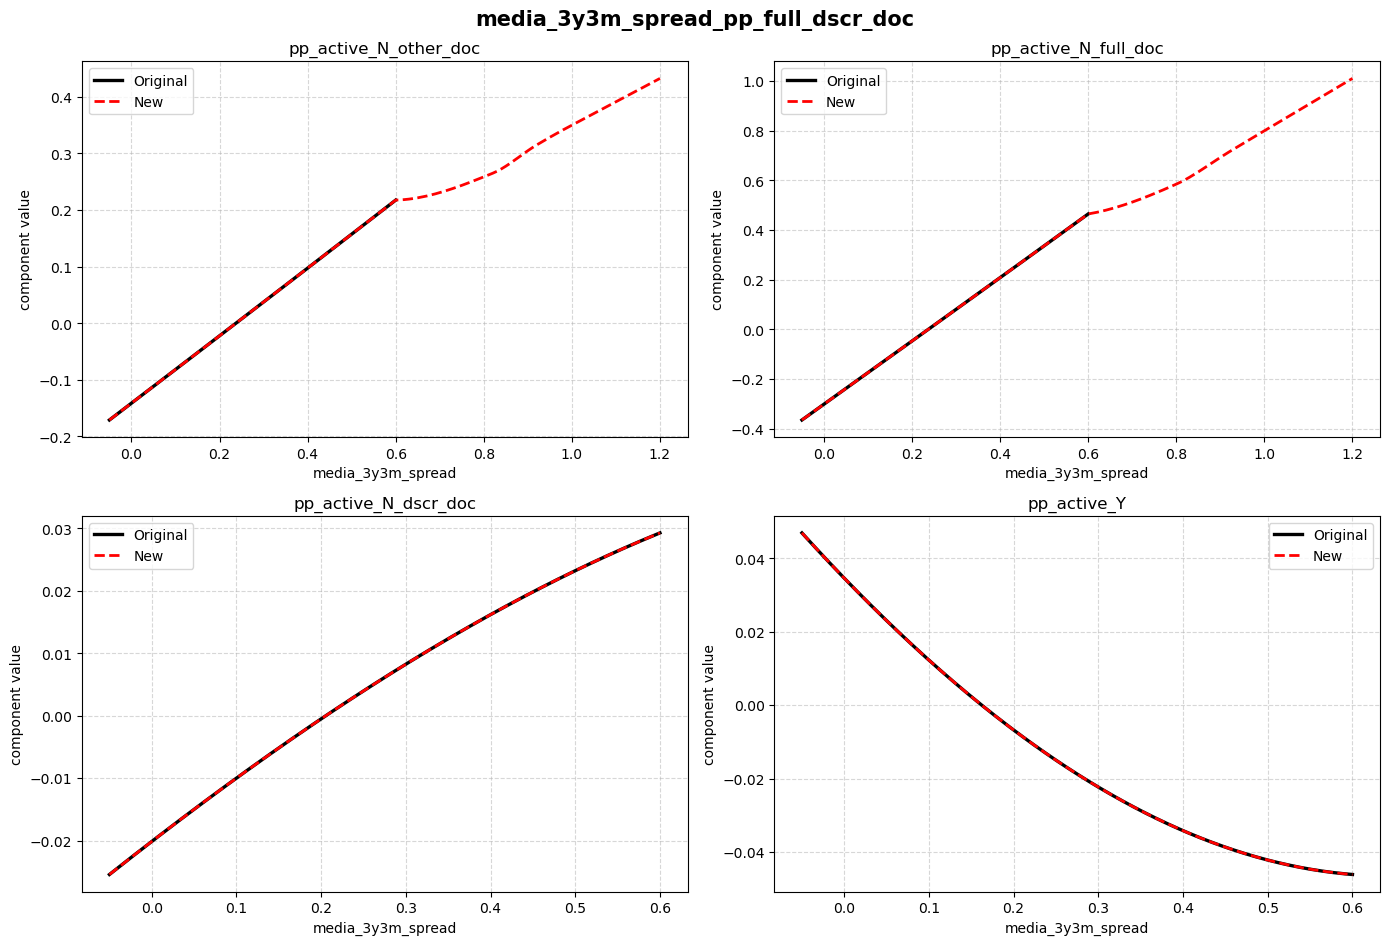

In [7]:
def plot_media_before_after(selector_values: tuple[str, ...] = SELECTOR_VALUES) -> None:
    ncols = 2
    nrows = (len(selector_values) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.8 * nrows), squeeze=False)
    axes_flat = axes.ravel()

    for ax, selector_value in zip(axes_flat, selector_values, strict=False):
        df_original = original_curves[selector_value]
        df_new = new_curves[selector_value]

        ax.plot(df_original["x"], df_original["y"], color="black", linewidth=2.4, label="Original")
        ax.plot(df_new["x"], df_new["y"], "--", color="red", linewidth=2.0, label="New")
        ax.set_title(selector_value)
        ax.set_xlabel("media_3y3m_spread")
        ax.set_ylabel("component value")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(frameon=True)

    for ax in axes_flat[len(selector_values) :]:
        ax.set_visible(False)

    fig.suptitle(CURVE_NAME, fontsize=15, weight="bold")
    fig.tight_layout()
    plt.show()


plot_media_before_after()

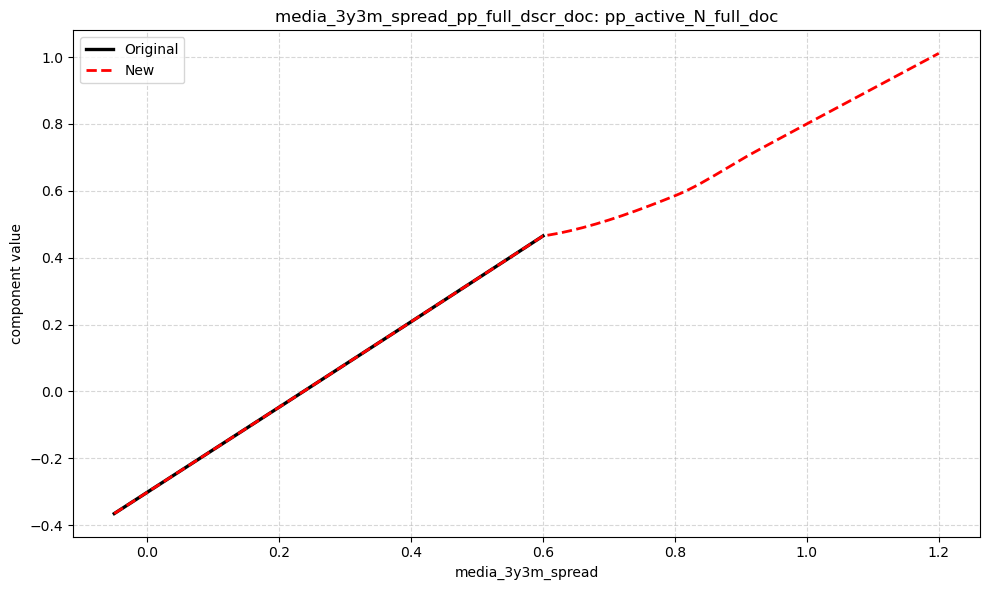

In [8]:
SELECTOR_VALUE = "pp_active_N_full_doc"

df_original = original_curves[SELECTOR_VALUE]
df_new = new_curves[SELECTOR_VALUE]

plt.figure(figsize=(10, 6))
plt.plot(df_original["x"], df_original["y"], color="black", linewidth=2.4, label="Original")
plt.plot(df_new["x"], df_new["y"], "--", color="red", linewidth=2.0, label="New")
plt.title(f"{CURVE_NAME}: {SELECTOR_VALUE}")
plt.xlabel("media_3y3m_spread")
plt.ylabel("component value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

## Write Edited JSON

Run this only after the plots look right. It writes a new auto-suffixed file under `smooth/local_models/` and does not modify the source JSON.

In [42]:
written_path = write_model_json(model_edit, OUTPUT_PATH)
print(f"Wrote edited model to: {written_path}")

Wrote edited model to: s:\QR\hzeng\howard-toolbox\smooth\local_models\refi_fixed_v1_2026_05_27_11_24_28.746427.smooth_edit.json
